# Phase 1.2: Realistic Channel Modeling Demonstration

This notebook demonstrates production-grade channel models per 3GPP specifications:
- 3GPP TR 38.901 TDL channel models (TDL-A/B/C/D/E)
- Jakes' sum-of-sinusoids time-varying fading with Doppler
- Hardware impairments (CFO, SFO, I/Q imbalance, DC offset, phase noise, PA nonlinearity)
- MIMO with spatial correlation

All implementations based on 3GPP specifications with proper citations.

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt

from utils_channel import (
    add_awgn,
    generate_tdl_channel,
    apply_tdl_channel,
    generate_rayleigh_fading_jakes,
    generate_rician_fading_jakes,
    apply_cfo,
    apply_sfo,
    apply_iq_imbalance,
    apply_dc_offset,
    apply_phase_noise,
    apply_pa_nonlinearity,
    generate_mimo_channel,
    TDL_MODELS
)

from run_lte import generate_lte_signal

print('Channel modeling imports successful')

Channel modeling imports successful


## 1. 3GPP TDL Channel Models

3GPP TR 38.901 TDL (Tapped Delay Line) models replace obsolete ITU profiles.

In [2]:
# Show all TDL models
print('3GPP TR 38.901 TDL Models:')
print('=' * 80)
for model_name, model_info in TDL_MODELS.items():
    print(f"\n{model_name}: {model_info['description']}")
    print(f"  Number of taps: {len(model_info['delays_normalized'])}")
    print(f"  Typical delay spread: {model_info['typical_ds_ns']} ns")
    if model_name in ['TDL-D', 'TDL-E']:
        k_factor = model_info['k_factors_db'][0]
        print(f"  K-factor (LOS): {k_factor} dB")

3GPP TR 38.901 TDL Models:

TDL-A: NLOS, low delay spread (23 taps)
  Number of taps: 23
  Typical delay spread: 30 ns

TDL-B: NLOS, medium delay spread (23 taps)
  Number of taps: 23
  Typical delay spread: 100 ns

TDL-C: NLOS, high delay spread (24 taps)
  Number of taps: 24
  Typical delay spread: 300 ns

TDL-D: LOS, low delay spread (13 taps, K=13.3 dB)
  Number of taps: 13
  Typical delay spread: 30 ns
  K-factor (LOS): 13.3 dB

TDL-E: LOS, high delay spread (14 taps, K=22 dB)
  Number of taps: 14
  Typical delay spread: 300 ns
  K-factor (LOS): 22 dB


Channel coefficients shape: torch.Size([23, 5000])
Number of taps: 23
Total channel power: 1.000000


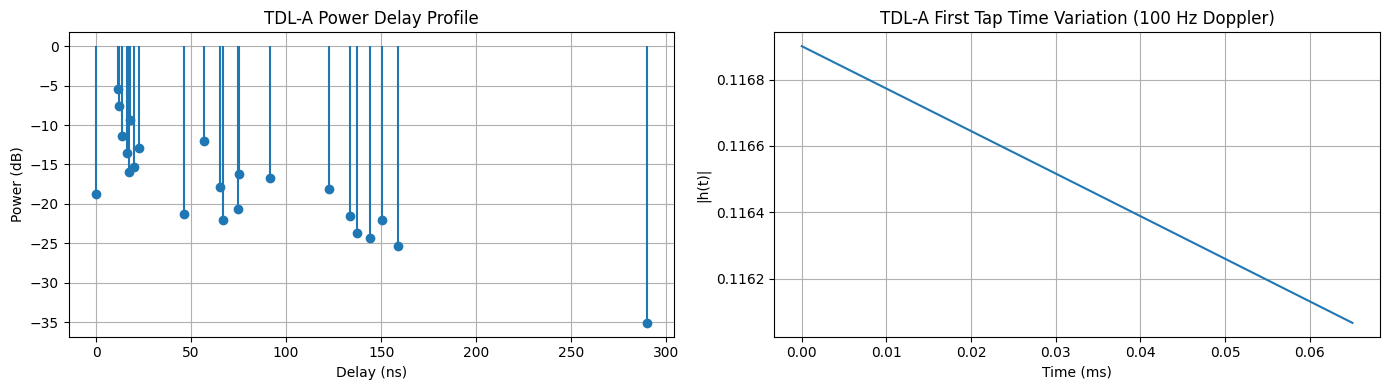

In [3]:
# Generate and visualize TDL-A channel
num_samples = 5000
sample_rate = 15.36e6

channel_coeffs, delays_ns, powers = generate_tdl_channel(
    num_samples=num_samples,
    tdl_model='TDL-A',
    sample_rate=sample_rate,
    doppler_hz=100,
    device='cpu'
)

print(f"Channel coefficients shape: {channel_coeffs.shape}")
print(f"Number of taps: {len(delays_ns)}")
print(f"Total channel power: {sum(powers):.6f}")

# Plot power delay profile
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Power delay profile
axes[0].stem(delays_ns, 10*np.log10(powers), basefmt=' ')
axes[0].set_xlabel('Delay (ns)')
axes[0].set_ylabel('Power (dB)')
axes[0].set_title('TDL-A Power Delay Profile')
axes[0].grid(True)

# Time-varying fading for first tap
t = np.arange(1000) / sample_rate * 1000
h0 = channel_coeffs[0, :1000].cpu().numpy()
axes[1].plot(t, np.abs(h0))
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('|h(t)|')
axes[1].set_title('TDL-A First Tap Time Variation (100 Hz Doppler)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

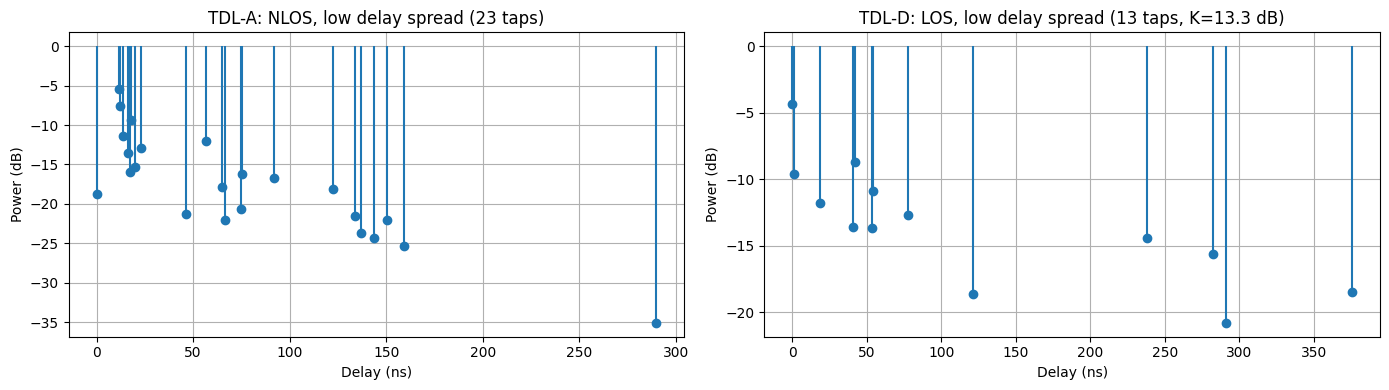

In [4]:
# Compare NLOS (TDL-A) vs LOS (TDL-D)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for idx, model_name in enumerate(['TDL-A', 'TDL-D']):
    coeffs, delays, powers = generate_tdl_channel(
        num_samples=1000,
        tdl_model=model_name,
        sample_rate=sample_rate,
        device='cpu'
    )
    
    axes[idx].stem(delays, 10*np.log10(powers), basefmt=' ')
    axes[idx].set_xlabel('Delay (ns)')
    axes[idx].set_ylabel('Power (dB)')
    axes[idx].set_title(f'{model_name}: {TDL_MODELS[model_name]["description"]}')
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

## 2. Jakes' Time-Varying Fading

Jakes' sum-of-sinusoids model for Rayleigh/Rician fading with Doppler effects.

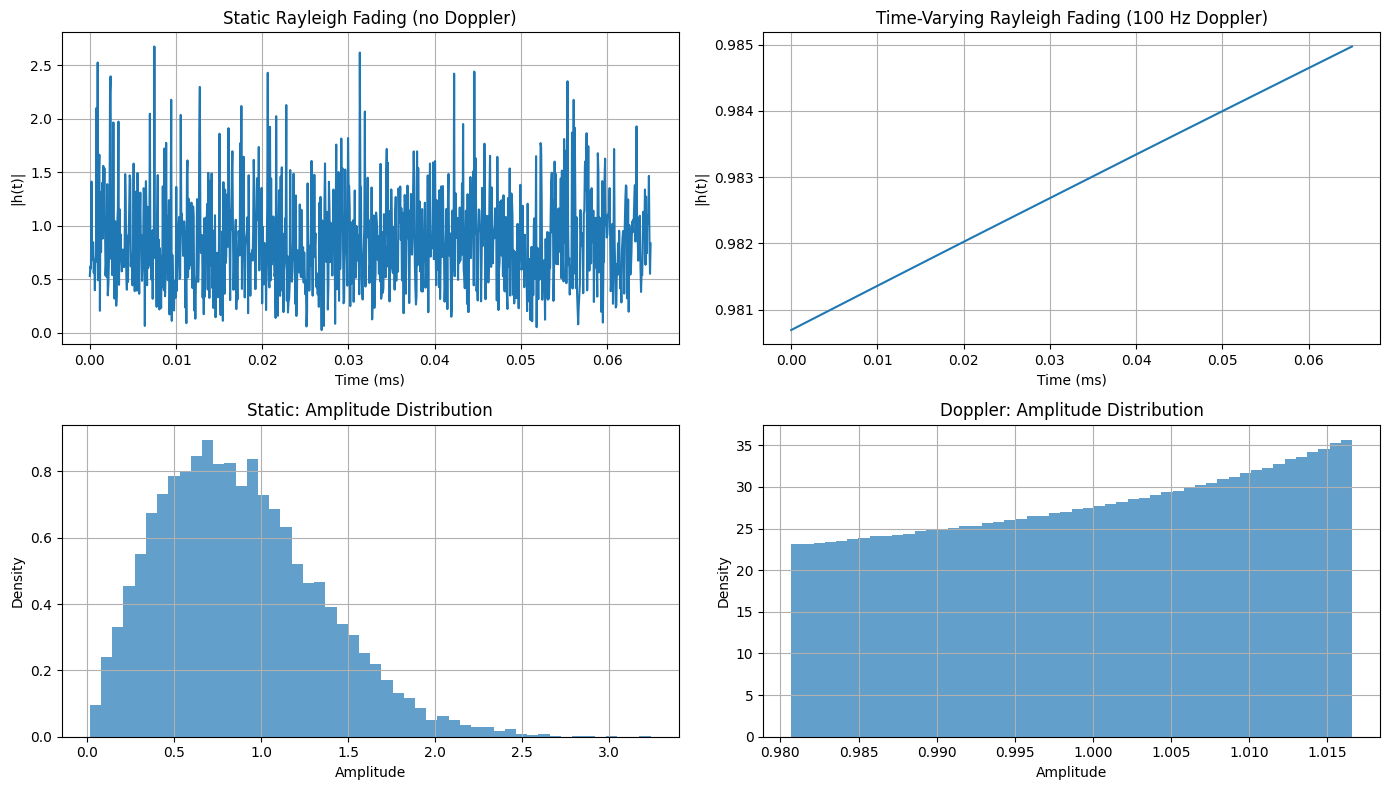

Static: Mean power = 0.990063
Doppler: Mean power = 1.000000


In [5]:
# Compare static vs time-varying Rayleigh fading
num_samples = 10000

h_static = generate_rayleigh_fading_jakes(num_samples, doppler_freq=0)
h_doppler = generate_rayleigh_fading_jakes(num_samples, doppler_freq=100, sample_rate=15.36e6)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Static fading
t = np.arange(1000) / 15.36e6 * 1000
h_static_np = h_static[:1000].cpu().numpy()
axes[0, 0].plot(t, np.abs(h_static_np))
axes[0, 0].set_xlabel('Time (ms)')
axes[0, 0].set_ylabel('|h(t)|')
axes[0, 0].set_title('Static Rayleigh Fading (no Doppler)')
axes[0, 0].grid(True)

# Time-varying fading
h_doppler_np = h_doppler[:1000].cpu().numpy()
axes[0, 1].plot(t, np.abs(h_doppler_np))
axes[0, 1].set_xlabel('Time (ms)')
axes[0, 1].set_ylabel('|h(t)|')
axes[0, 1].set_title('Time-Varying Rayleigh Fading (100 Hz Doppler)')
axes[0, 1].grid(True)

# Amplitude distributions
axes[1, 0].hist(np.abs(h_static.cpu().numpy()), bins=50, density=True, alpha=0.7)
axes[1, 0].set_xlabel('Amplitude')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Static: Amplitude Distribution')
axes[1, 0].grid(True)

axes[1, 1].hist(np.abs(h_doppler.cpu().numpy()), bins=50, density=True, alpha=0.7)
axes[1, 1].set_xlabel('Amplitude')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Doppler: Amplitude Distribution')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print(f"Static: Mean power = {torch.mean(torch.abs(h_static)**2).item():.6f}")
print(f"Doppler: Mean power = {torch.mean(torch.abs(h_doppler)**2).item():.6f}")

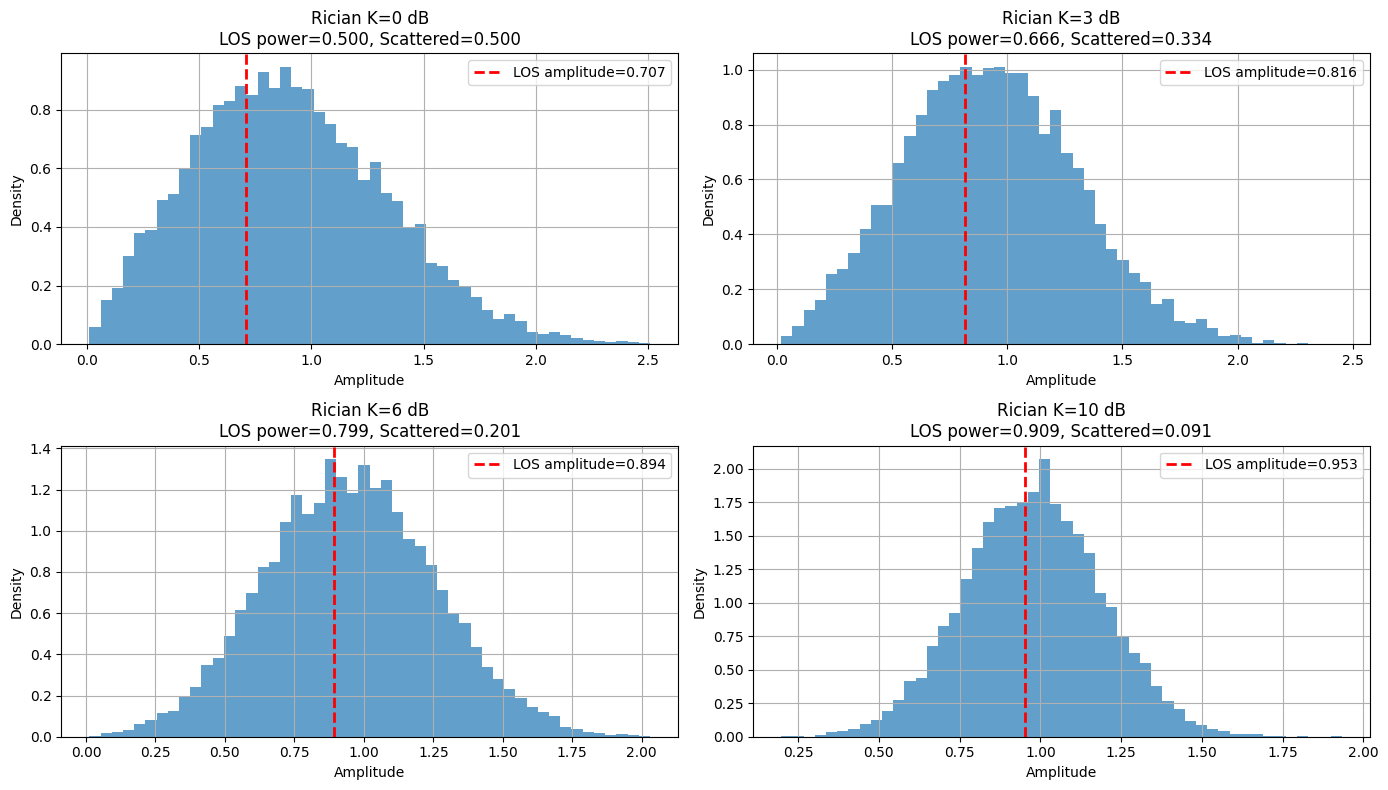

In [6]:
# Rician fading with different K-factors
k_factors = [0, 3, 6, 10]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, k_db in enumerate(k_factors):
    row, col = idx // 2, idx % 2
    
    # Generate Rician fading
    h = generate_rician_fading_jakes(10000, k_factor_db=k_db)
    h_np = h.cpu().numpy()
    
    # Calculate LOS and scattered power
    k_linear = 10 ** (k_db / 10.0)
    los_power = k_linear / (k_linear + 1)
    scattered_power = 1.0 / (k_linear + 1)
    
    # Plot amplitude histogram
    axes[row, col].hist(np.abs(h_np), bins=50, density=True, alpha=0.7)
    
    # Show LOS component as vertical line
    los_amplitude = np.sqrt(los_power)
    axes[row, col].axvline(los_amplitude, color='red', linestyle='--', linewidth=2, 
                           label=f'LOS amplitude={los_amplitude:.3f}')
    
    axes[row, col].set_xlabel('Amplitude')
    axes[row, col].set_ylabel('Density')
    axes[row, col].set_title(f'Rician K={k_db} dB\nLOS power={los_power:.3f}, Scattered={scattered_power:.3f}')
    axes[row, col].legend()
    axes[row, col].grid(True)

plt.tight_layout()
plt.show()

## 3. Hardware Impairments

Realistic RF hardware imperfections per 3GPP specifications.

In [7]:
# Generate clean LTE signal for testing
lte_result = generate_lte_signal(
    duration_ms=1.0,
    bandwidth_mhz=10.0,
    modulation_scheme='16QAM',
    power_dbm=0.0,
    device='cpu'
)

clean_signal = lte_result['signal']
lte_sample_rate = lte_result['metadata']['sample_rate']

print(f"LTE signal: {len(clean_signal)} samples at {lte_sample_rate/1e6:.2f} MHz")
print(f"Signal power: {torch.mean(torch.abs(clean_signal)**2).item():.6f}")

LTE signal: 15360 samples at 15.36 MHz
Signal power: 1.000000


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


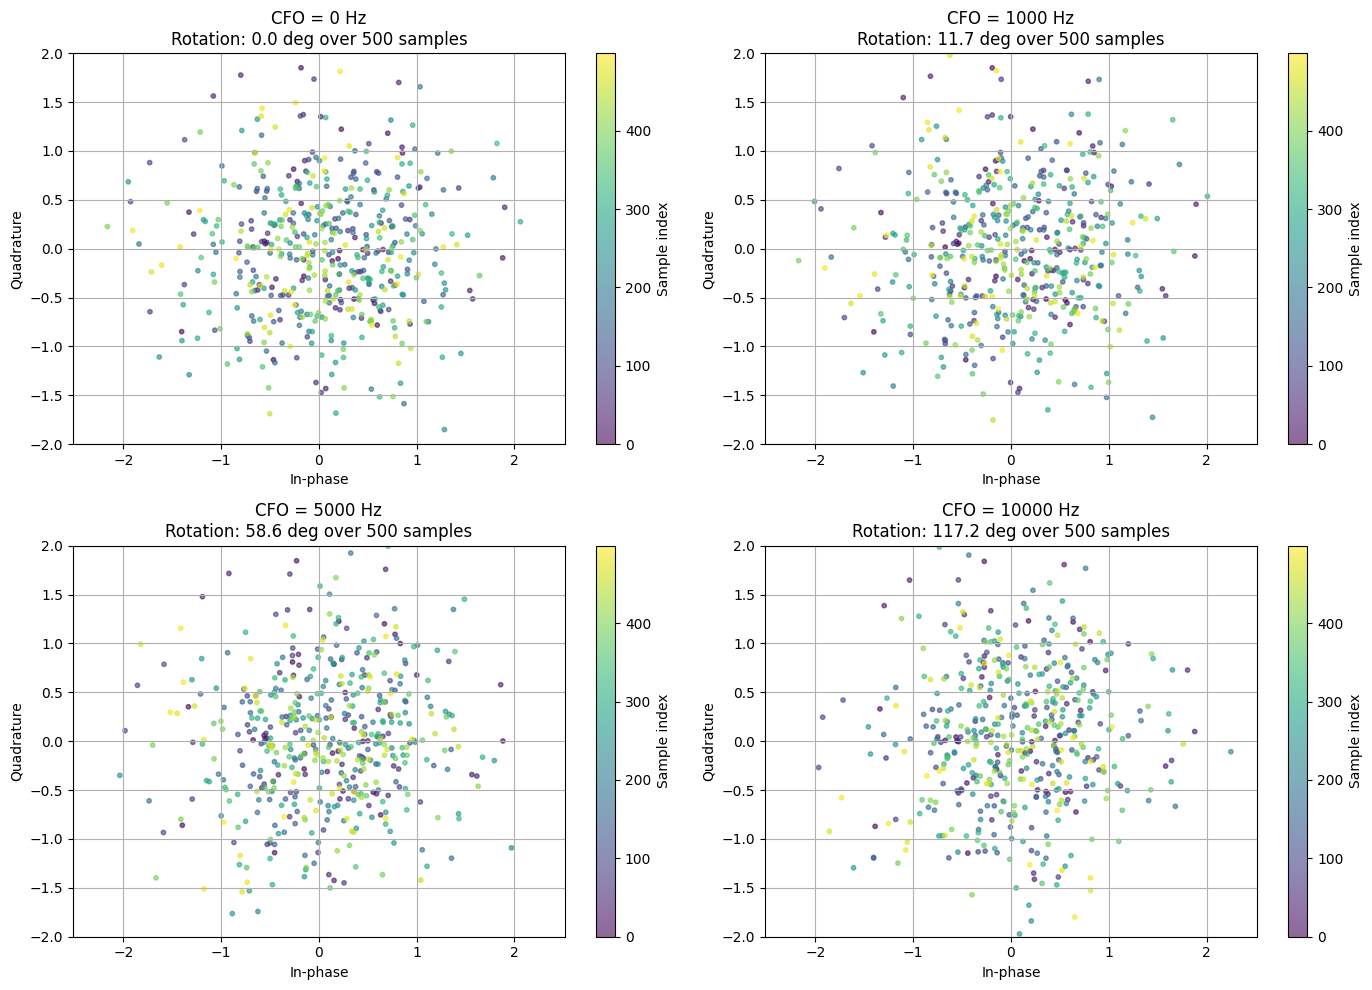


CFO Rotation Analysis:
Sample rate: 15.36 MHz
CFO     0 Hz: Full rotation every      inf samples (inf ms)
CFO  1000 Hz: Full rotation every  15360.0 samples (1.000 ms)
CFO  5000 Hz: Full rotation every   3072.0 samples (0.200 ms)
CFO 10000 Hz: Full rotation every   1536.0 samples (0.100 ms)


In [8]:
# CFO effect on constellation - showing phase rotation over time
cfo_values = [0, 1000, 5000, 10000]  # Hz
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, cfo_hz in enumerate(cfo_values):
    row, col = idx // 2, idx % 2
    
    signal_with_cfo = apply_cfo(clean_signal, cfo_hz, lte_sample_rate)
    
    # Take a small window to see rotation clearly
    window_start = 0
    window_samples = 500
    sig_window = signal_with_cfo[window_start:window_start+window_samples].cpu().numpy()
    
    # Color by time to show rotation
    time_indices = np.arange(len(sig_window))
    scatter = axes[row, col].scatter(sig_window.real, sig_window.imag, 
                                      c=time_indices, cmap='viridis', 
                                      alpha=0.6, s=10)
    
    axes[row, col].set_xlabel('In-phase')
    axes[row, col].set_ylabel('Quadrature')
    
    # Calculate rotation per sample
    rotation_per_sample = cfo_hz / lte_sample_rate * 360  # degrees
    total_rotation = rotation_per_sample * window_samples
    
    axes[row, col].set_title(f'CFO = {cfo_hz} Hz\nRotation: {total_rotation:.1f} deg over {window_samples} samples')
    axes[row, col].grid(True)
    axes[row, col].axis('equal')
    axes[row, col].set_xlim(-2, 2)
    axes[row, col].set_ylim(-2, 2)
    
    # Add colorbar to show time progression
    plt.colorbar(scatter, ax=axes[row, col], label='Sample index')

plt.tight_layout()
plt.show()

print("\nCFO Rotation Analysis:")
print(f"Sample rate: {lte_sample_rate/1e6:.2f} MHz")
for cfo_hz in cfo_values:
    period_samples = lte_sample_rate / cfo_hz if cfo_hz > 0 else float('inf')
    print(f"CFO {cfo_hz:5d} Hz: Full rotation every {period_samples:8.1f} samples ({period_samples/lte_sample_rate*1000:.3f} ms)")

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


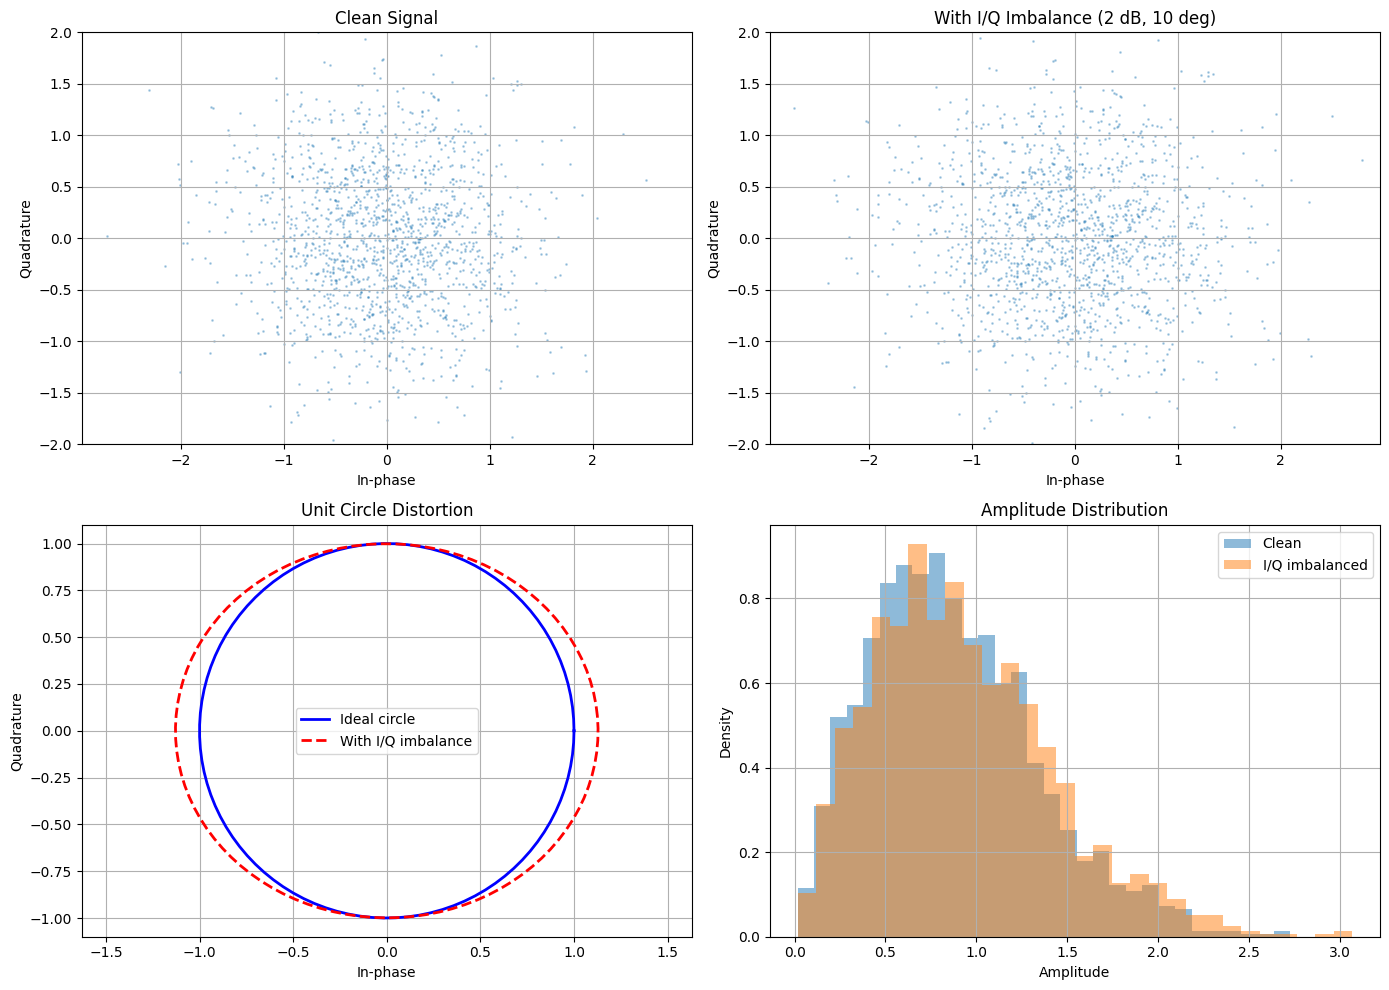

I/Q imbalance turns circles into ellipses - causes image frequency interference


In [9]:
# I/Q imbalance effect - showing amplitude and phase distortion
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Clean signal
clean_np = clean_signal.cpu().numpy()[::10]
axes[0, 0].scatter(clean_np.real, clean_np.imag, alpha=0.3, s=1)
axes[0, 0].set_xlabel('In-phase')
axes[0, 0].set_ylabel('Quadrature')
axes[0, 0].set_title('Clean Signal')
axes[0, 0].grid(True)
axes[0, 0].axis('equal')
axes[0, 0].set_xlim(-2, 2)
axes[0, 0].set_ylim(-2, 2)

# With I/Q imbalance
iq_imbalanced = apply_iq_imbalance(clean_signal, amplitude_imb_db=2.0, phase_imb_deg=10.0)
iq_np = iq_imbalanced.cpu().numpy()[::10]
axes[0, 1].scatter(iq_np.real, iq_np.imag, alpha=0.3, s=1)
axes[0, 1].set_xlabel('In-phase')
axes[0, 1].set_ylabel('Quadrature')
axes[0, 1].set_title('With I/Q Imbalance (2 dB, 10 deg)')
axes[0, 1].grid(True)
axes[0, 1].axis('equal')
axes[0, 1].set_xlim(-2, 2)
axes[0, 1].set_ylim(-2, 2)

# Show distortion on unit circle
angles = np.linspace(0, 2*np.pi, 100)
unit_circle = np.exp(1j * angles)
unit_torch = torch.from_numpy(unit_circle).to(torch.complex64)

# Apply I/Q imbalance to unit circle
distorted_circle = apply_iq_imbalance(unit_torch, amplitude_imb_db=2.0, phase_imb_deg=10.0)
distorted_np = distorted_circle.cpu().numpy()

axes[1, 0].plot(unit_circle.real, unit_circle.imag, 'b-', linewidth=2, label='Ideal circle')
axes[1, 0].plot(distorted_np.real, distorted_np.imag, 'r--', linewidth=2, label='With I/Q imbalance')
axes[1, 0].set_xlabel('In-phase')
axes[1, 0].set_ylabel('Quadrature')
axes[1, 0].set_title('Unit Circle Distortion')
axes[1, 0].grid(True)
axes[1, 0].axis('equal')
axes[1, 0].legend()

# Amplitude comparison
axes[1, 1].hist(np.abs(clean_np), bins=30, alpha=0.5, label='Clean', density=True)
axes[1, 1].hist(np.abs(iq_np), bins=30, alpha=0.5, label='I/Q imbalanced', density=True)
axes[1, 1].set_xlabel('Amplitude')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Amplitude Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print("I/Q imbalance turns circles into ellipses - causes image frequency interference")

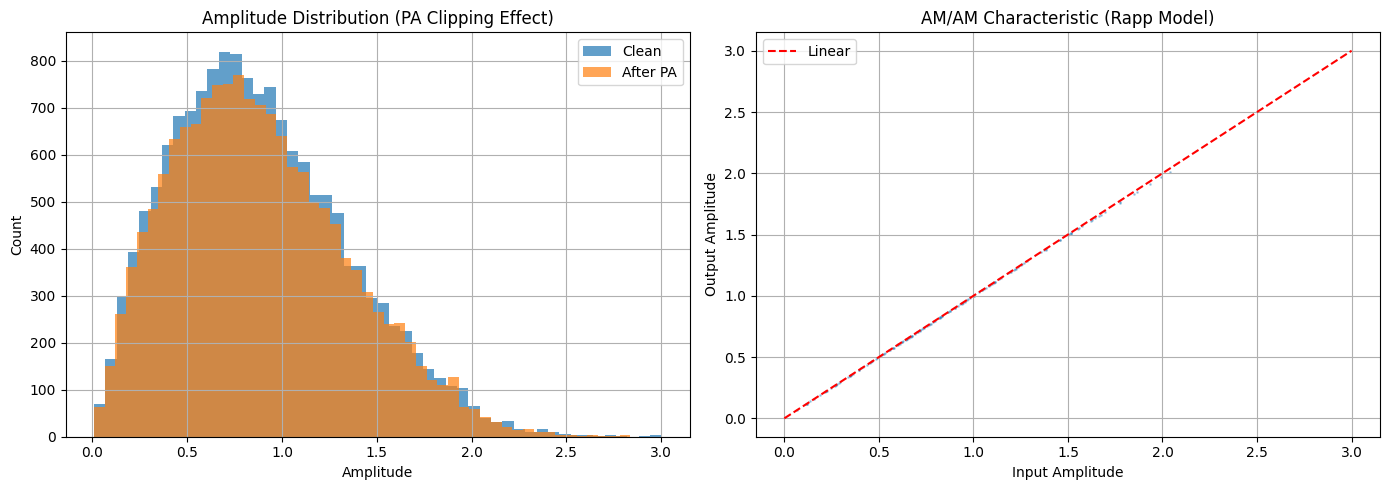

In [10]:
# PA nonlinearity (clipping)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amplitude distribution before PA
clean_amp = np.abs(clean_signal.cpu().numpy())
axes[0].hist(clean_amp, bins=50, alpha=0.7, label='Clean')

# After PA nonlinearity
amplified = apply_pa_nonlinearity(clean_signal, input_backoff_db=3.0)
amp_np = np.abs(amplified.cpu().numpy())
axes[0].hist(amp_np, bins=50, alpha=0.7, label='After PA')
axes[0].set_xlabel('Amplitude')
axes[0].set_ylabel('Count')
axes[0].set_title('Amplitude Distribution (PA Clipping Effect)')
axes[0].legend()
axes[0].grid(True)

# AM/AM characteristic
axes[1].scatter(clean_amp[::100], amp_np[::100], alpha=0.3, s=1)
axes[1].plot([0, clean_amp.max()], [0, clean_amp.max()], 'r--', label='Linear')
axes[1].set_xlabel('Input Amplitude')
axes[1].set_ylabel('Output Amplitude')
axes[1].set_title('AM/AM Characteristic (Rapp Model)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

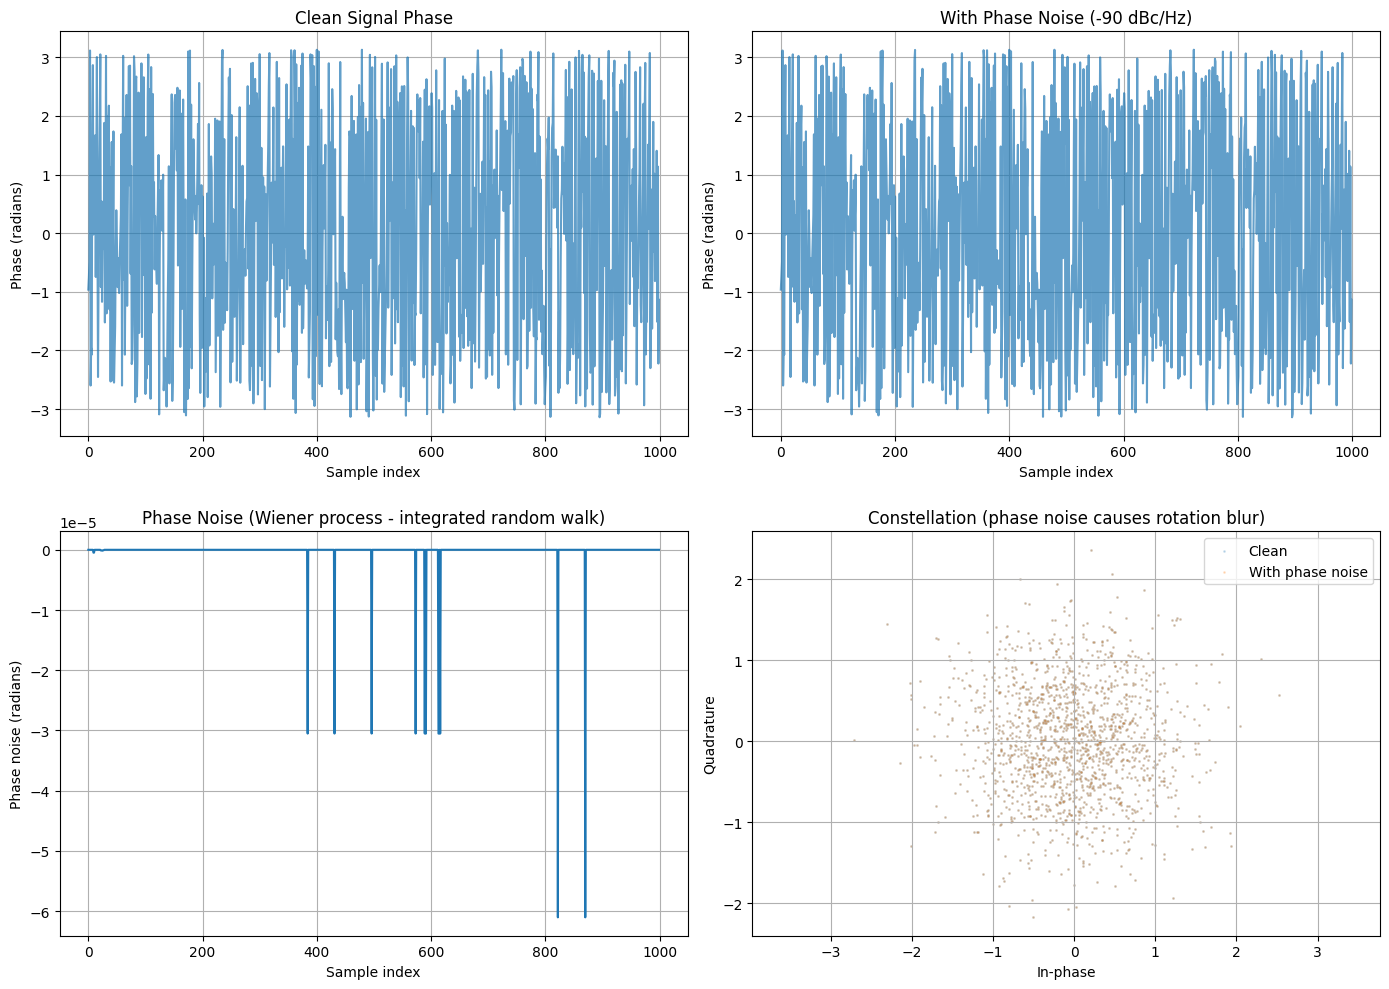

Phase noise preserves amplitude: relative difference = 0.000%
Phase noise is a random walk (Wiener process) - cumulative over time


In [11]:
# Phase noise effect - showing phase variation over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Generate multiple realizations to show randomness
pn_level = -90

# Clean signal phase
clean_subset = clean_signal[:1000].cpu().numpy()
clean_phase = np.angle(clean_subset)

axes[0, 0].plot(clean_phase, alpha=0.7)
axes[0, 0].set_xlabel('Sample index')
axes[0, 0].set_ylabel('Phase (radians)')
axes[0, 0].set_title('Clean Signal Phase')
axes[0, 0].grid(True)

# With phase noise - show phase variation
with_pn = apply_phase_noise(clean_signal[:1000], phase_noise_dbc_hz=pn_level, sample_rate=lte_sample_rate)
pn_phase = np.angle(with_pn.cpu().numpy())

axes[0, 1].plot(pn_phase, alpha=0.7)
axes[0, 1].set_xlabel('Sample index')
axes[0, 1].set_ylabel('Phase (radians)')
axes[0, 1].set_title(f'With Phase Noise ({pn_level} dBc/Hz)')
axes[0, 1].grid(True)

# Phase difference (the actual phase noise)
phase_diff = np.unwrap(pn_phase) - np.unwrap(clean_phase)
axes[1, 0].plot(phase_diff)
axes[1, 0].set_xlabel('Sample index')
axes[1, 0].set_ylabel('Phase noise (radians)')
axes[1, 0].set_title('Phase Noise (Wiener process - integrated random walk)')
axes[1, 0].grid(True)

# Constellation comparison
clean_np = clean_signal.cpu().numpy()[::10]
pn_full = apply_phase_noise(clean_signal, phase_noise_dbc_hz=pn_level, sample_rate=lte_sample_rate)
pn_np = pn_full.cpu().numpy()[::10]

axes[1, 1].scatter(clean_np.real, clean_np.imag, alpha=0.2, s=1, label='Clean')
axes[1, 1].scatter(pn_np.real, pn_np.imag, alpha=0.2, s=1, label='With phase noise')
axes[1, 1].set_xlabel('In-phase')
axes[1, 1].set_ylabel('Quadrature')
axes[1, 1].set_title('Constellation (phase noise causes rotation blur)')
axes[1, 1].grid(True)
axes[1, 1].axis('equal')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Show phase noise preserves amplitude
amp_original = torch.abs(clean_signal)
amp_noisy = torch.abs(pn_full)
relative_diff = torch.mean(torch.abs(amp_original - amp_noisy) / amp_original).item()
print(f"Phase noise preserves amplitude: relative difference = {relative_diff*100:.3f}%")
print(f"Phase noise is a random walk (Wiener process) - cumulative over time")

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


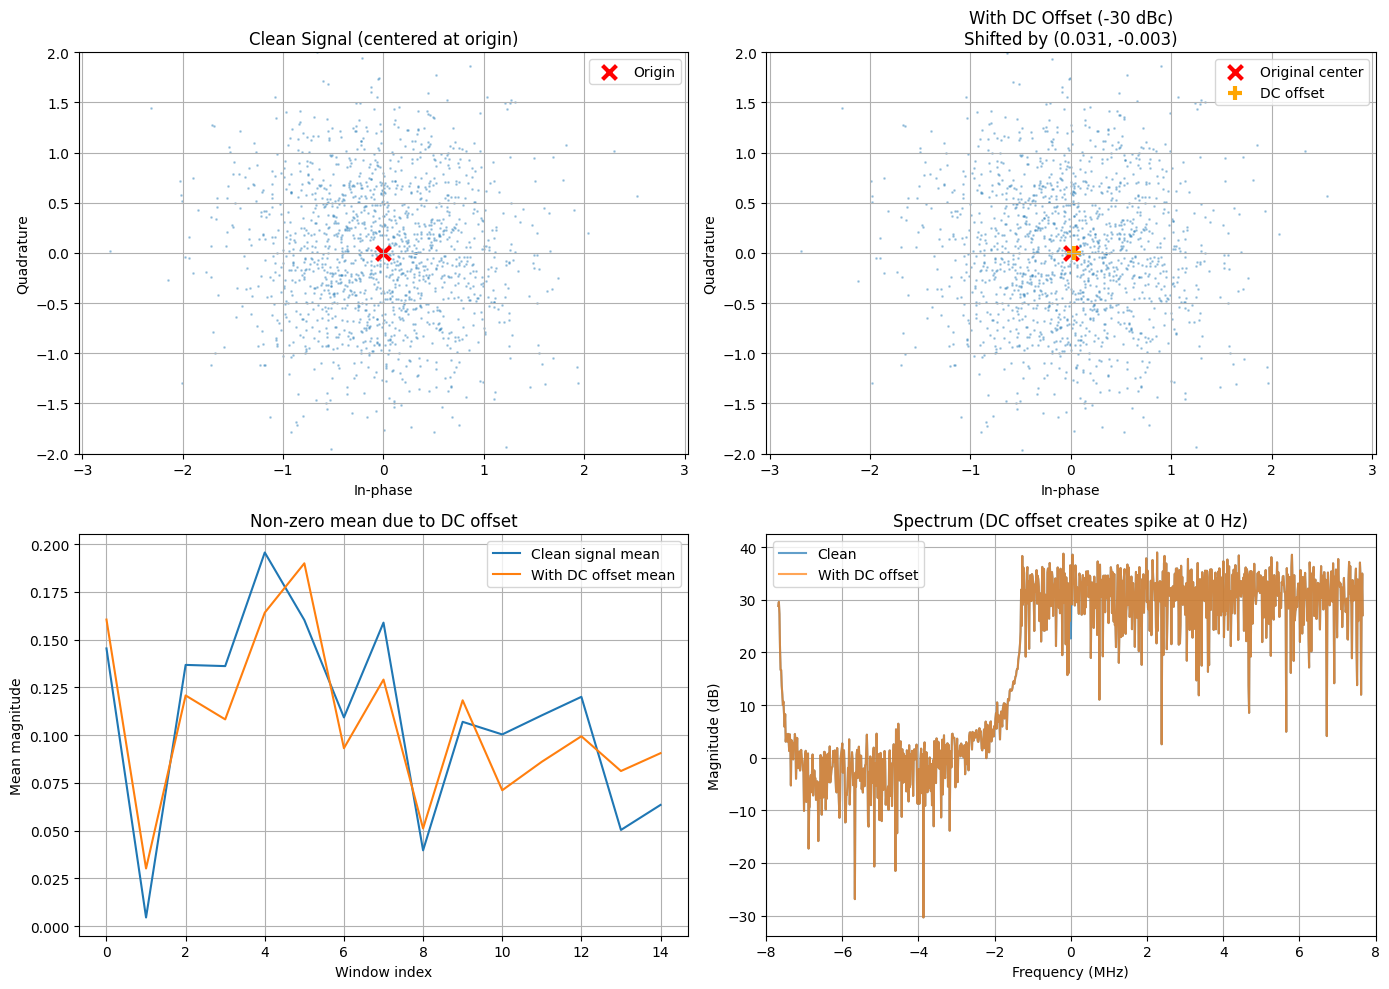

DC offset shifts entire constellation by constant complex value
DC offset magnitude: 0.031623
Caused by LO (Local Oscillator) leakage in zero-IF receivers


In [12]:
# DC offset effect - showing constant shift
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Clean signal
clean_np = clean_signal.cpu().numpy()[::10]
axes[0, 0].scatter(clean_np.real, clean_np.imag, alpha=0.3, s=1)
axes[0, 0].scatter([0], [0], c='red', s=100, marker='x', linewidths=3, label='Origin')
axes[0, 0].set_xlabel('In-phase')
axes[0, 0].set_ylabel('Quadrature')
axes[0, 0].set_title('Clean Signal (centered at origin)')
axes[0, 0].grid(True)
axes[0, 0].axis('equal')
axes[0, 0].set_xlim(-2, 2)
axes[0, 0].set_ylim(-2, 2)
axes[0, 0].legend()

# With DC offset
with_dc = apply_dc_offset(clean_signal, dc_level_dbc=-30)
dc_np = with_dc.cpu().numpy()[::10]

# Calculate DC offset value
dc_value = torch.mean(with_dc - clean_signal)
dc_real = dc_value.real.item()
dc_imag = dc_value.imag.item()

axes[0, 1].scatter(dc_np.real, dc_np.imag, alpha=0.3, s=1)
axes[0, 1].scatter([0], [0], c='red', s=100, marker='x', linewidths=3, label='Original center')
axes[0, 1].scatter([dc_real], [dc_imag], c='orange', s=100, marker='+', linewidths=3, label='DC offset')
axes[0, 1].set_xlabel('In-phase')
axes[0, 1].set_ylabel('Quadrature')
axes[0, 1].set_title(f'With DC Offset (-30 dBc)\nShifted by ({dc_real:.3f}, {dc_imag:.3f})')
axes[0, 1].grid(True)
axes[0, 1].axis('equal')
axes[0, 1].set_xlim(-2, 2)
axes[0, 1].set_ylim(-2, 2)
axes[0, 1].legend()

# Show mean over time
window = 100
clean_means = [np.mean(clean_np[i:i+window]) for i in range(0, len(clean_np)-window, window)]
dc_means = [np.mean(dc_np[i:i+window]) for i in range(0, len(dc_np)-window, window)]

axes[1, 0].plot(np.abs(clean_means), label='Clean signal mean')
axes[1, 0].plot(np.abs(dc_means), label='With DC offset mean')
axes[1, 0].set_xlabel('Window index')
axes[1, 0].set_ylabel('Mean magnitude')
axes[1, 0].set_title('Non-zero mean due to DC offset')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Spectrum view (FFT to show DC spike)
from scipy.fft import fft, fftshift, fftfreq
n_fft = 1024
clean_fft = fftshift(fft(clean_signal[:n_fft].cpu().numpy()))
dc_fft = fftshift(fft(with_dc[:n_fft].cpu().numpy()))
freqs = fftshift(fftfreq(n_fft, 1/lte_sample_rate)) / 1e6  # MHz

axes[1, 1].plot(freqs, 20*np.log10(np.abs(clean_fft)), label='Clean', alpha=0.7)
axes[1, 1].plot(freqs, 20*np.log10(np.abs(dc_fft)), label='With DC offset', alpha=0.7)
axes[1, 1].set_xlabel('Frequency (MHz)')
axes[1, 1].set_ylabel('Magnitude (dB)')
axes[1, 1].set_title('Spectrum (DC offset creates spike at 0 Hz)')
axes[1, 1].set_xlim(-8, 8)
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

dc_magnitude = torch.abs(torch.mean(with_dc - clean_signal)).item()
print(f"DC offset shifts entire constellation by constant complex value")
print(f"DC offset magnitude: {dc_magnitude:.6f}")
print(f"Caused by LO (Local Oscillator) leakage in zero-IF receivers")

In [13]:
# SFO effect (timing drift)
print("\n6. Sampling Frequency Offset (SFO)")
for sfo_ppm in [1, 10, 50]:
    resampled = apply_sfo(clean_signal, sfo_ppm=sfo_ppm)
    print(f"  SFO {sfo_ppm} ppm: output length = {len(resampled)} (input = {len(clean_signal)})")


6. Sampling Frequency Offset (SFO)
  SFO 1 ppm: output length = 15360 (input = 15360)
  SFO 10 ppm: output length = 15360 (input = 15360)
  SFO 50 ppm: output length = 15360 (input = 15360)


## 4. MIMO Channels

MIMO channel generation with time-varying fading and spatial correlation.

MIMO channel shape: torch.Size([4, 4, 5000])


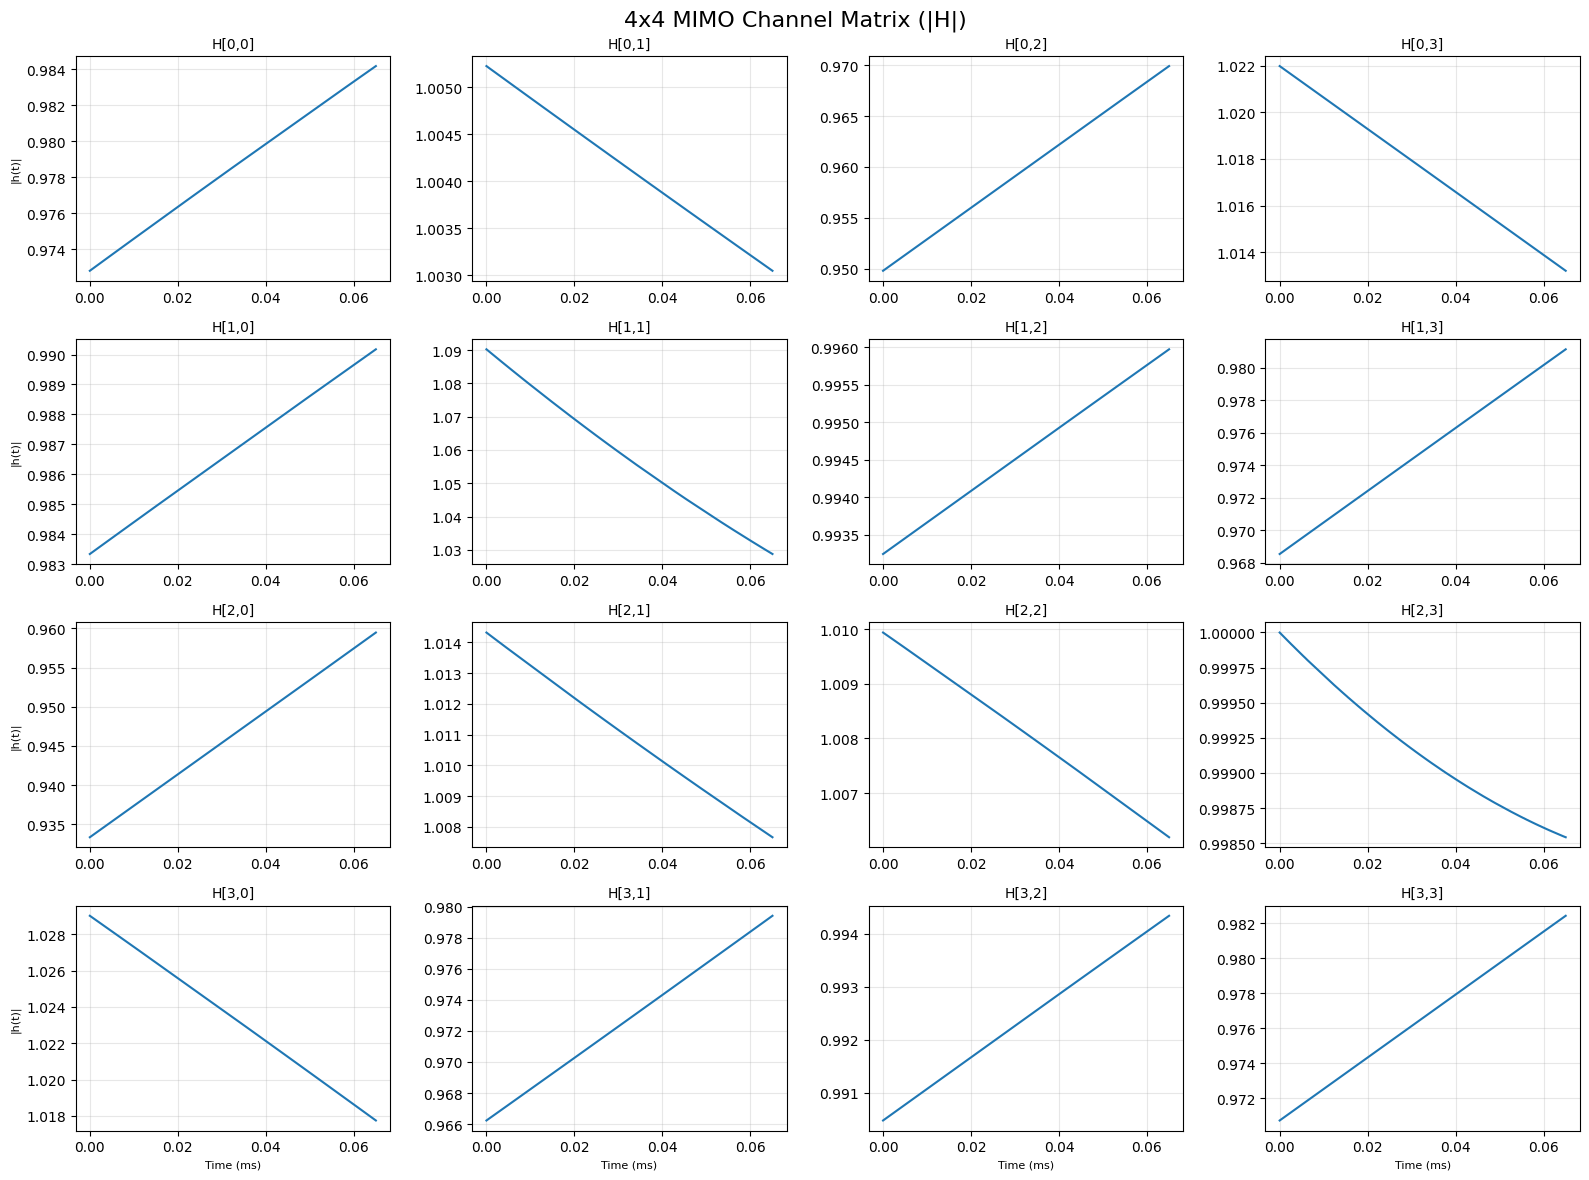

In [14]:
# Generate 4x4 MIMO channel
num_tx, num_rx = 4, 4
H = generate_mimo_channel(
    num_tx=num_tx,
    num_rx=num_rx,
    num_samples=5000,
    doppler_hz=100,
    sample_rate=15.36e6
)

print(f"MIMO channel shape: {H.shape}")

# Visualize channel matrix
fig, axes = plt.subplots(num_rx, num_tx, figsize=(16, 12))
fig.suptitle(f'{num_tx}x{num_rx} MIMO Channel Matrix (|H|)', fontsize=16)

for rx_idx in range(num_rx):
    for tx_idx in range(num_tx):
        h_element = H[rx_idx, tx_idx, :1000].cpu().numpy()
        t = np.arange(len(h_element)) / 15.36e6 * 1000
        
        axes[rx_idx, tx_idx].plot(t, np.abs(h_element))
        axes[rx_idx, tx_idx].set_title(f'H[{rx_idx},{tx_idx}]', fontsize=10)
        axes[rx_idx, tx_idx].grid(True, alpha=0.3)
        
        if rx_idx == num_rx - 1:
            axes[rx_idx, tx_idx].set_xlabel('Time (ms)', fontsize=8)
        if tx_idx == 0:
            axes[rx_idx, tx_idx].set_ylabel('|h(t)|', fontsize=8)

plt.tight_layout()
plt.show()

## 5. Realistic Combined Scenario

Complete channel with TDL + CFO + I/Q imbalance + AWGN applied to LTE signal.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


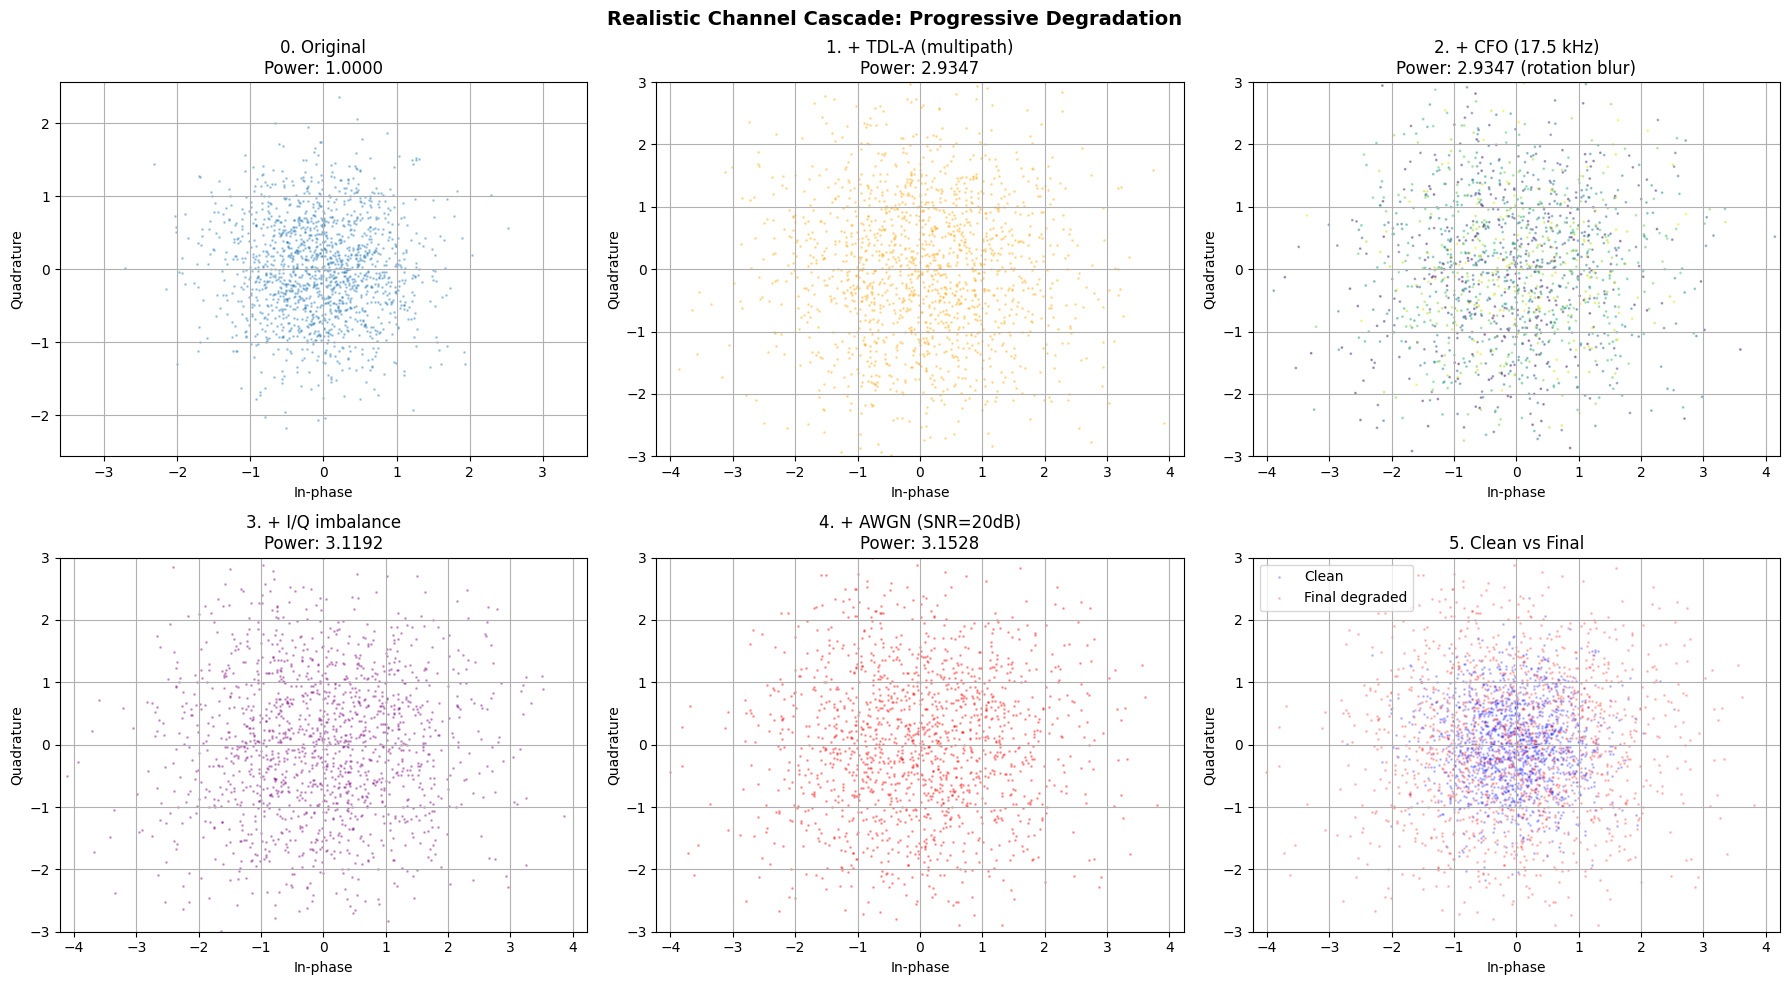


Cumulative Channel Effects:
Original:        Power = 1.0000
+ TDL-A:         Power = 2.9347 (multipath fading)
+ CFO:           Power = 2.9347 (phase rotation)
+ I/Q imbalance: Power = 3.1192 (ellipse distortion)
+ AWGN:          Power = 3.1528 (noise floor)

This simulates realistic urban NLOS scenario at 3.5 GHz


In [15]:
# Apply realistic channel cascade - showing cumulative degradation
signal_orig = clean_signal.clone()
signal = clean_signal.clone()

# Create figure with 5 subplots showing progression
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Step 0: Original
axes[0, 0].scatter(signal.cpu().numpy()[::10].real, signal.cpu().numpy()[::10].imag, alpha=0.3, s=1)
axes[0, 0].set_title(f'0. Original\nPower: {torch.mean(torch.abs(signal)**2).item():.4f}')
axes[0, 0].set_xlabel('In-phase')
axes[0, 0].set_ylabel('Quadrature')
axes[0, 0].grid(True)
axes[0, 0].axis('equal')
axes[0, 0].set_xlim(-3, 3)
axes[0, 0].set_ylim(-3, 3)

# Step 1: TDL-A multipath fading
signal = apply_tdl_channel(signal, tdl_model='TDL-A', doppler_hz=100, sample_rate=lte_sample_rate)
power1 = torch.mean(torch.abs(signal)**2).item()
axes[0, 1].scatter(signal.cpu().numpy()[::10].real, signal.cpu().numpy()[::10].imag, alpha=0.3, s=1, c='orange')
axes[0, 1].set_title(f'1. + TDL-A (multipath)\nPower: {power1:.4f}')
axes[0, 1].set_xlabel('In-phase')
axes[0, 1].set_ylabel('Quadrature')
axes[0, 1].grid(True)
axes[0, 1].axis('equal')
axes[0, 1].set_xlim(-3, 3)
axes[0, 1].set_ylim(-3, 3)

# Step 2: CFO (5 ppm at 3.5 GHz = 17.5 kHz)
signal = apply_cfo(signal, cfo_hz=17500, sample_rate=lte_sample_rate)
power2 = torch.mean(torch.abs(signal)**2).item()
sig_cfo = signal.cpu().numpy()[::10]
# Color by time to show rotation
time_color = np.arange(len(sig_cfo))
scatter = axes[0, 2].scatter(sig_cfo.real, sig_cfo.imag, alpha=0.4, s=1, c=time_color, cmap='viridis')
axes[0, 2].set_title(f'2. + CFO (17.5 kHz)\nPower: {power2:.4f} (rotation blur)')
axes[0, 2].set_xlabel('In-phase')
axes[0, 2].set_ylabel('Quadrature')
axes[0, 2].grid(True)
axes[0, 2].axis('equal')
axes[0, 2].set_xlim(-3, 3)
axes[0, 2].set_ylim(-3, 3)

# Step 3: I/Q imbalance
signal = apply_iq_imbalance(signal, amplitude_imb_db=1.0, phase_imb_deg=5.0)
power3 = torch.mean(torch.abs(signal)**2).item()
axes[1, 0].scatter(signal.cpu().numpy()[::10].real, signal.cpu().numpy()[::10].imag, alpha=0.3, s=1, c='purple')
axes[1, 0].set_title(f'3. + I/Q imbalance\nPower: {power3:.4f}')
axes[1, 0].set_xlabel('In-phase')
axes[1, 0].set_ylabel('Quadrature')
axes[1, 0].grid(True)
axes[1, 0].axis('equal')
axes[1, 0].set_xlim(-3, 3)
axes[1, 0].set_ylim(-3, 3)

# Step 4: AWGN (20 dB SNR)
signal = add_awgn(signal, snr_db=20)
power4 = torch.mean(torch.abs(signal)**2).item()
axes[1, 1].scatter(signal.cpu().numpy()[::10].real, signal.cpu().numpy()[::10].imag, alpha=0.3, s=1, c='red')
axes[1, 1].set_title(f'4. + AWGN (SNR=20dB)\nPower: {power4:.4f}')
axes[1, 1].set_xlabel('In-phase')
axes[1, 1].set_ylabel('Quadrature')
axes[1, 1].grid(True)
axes[1, 1].axis('equal')
axes[1, 1].set_xlim(-3, 3)
axes[1, 1].set_ylim(-3, 3)

# Summary comparison
axes[1, 2].scatter(signal_orig.cpu().numpy()[::10].real, signal_orig.cpu().numpy()[::10].imag, 
                   alpha=0.2, s=1, label='Clean', c='blue')
axes[1, 2].scatter(signal.cpu().numpy()[::10].real, signal.cpu().numpy()[::10].imag, 
                   alpha=0.2, s=1, label='Final degraded', c='red')
axes[1, 2].set_title('5. Clean vs Final')
axes[1, 2].set_xlabel('In-phase')
axes[1, 2].set_ylabel('Quadrature')
axes[1, 2].grid(True)
axes[1, 2].axis('equal')
axes[1, 2].set_xlim(-3, 3)
axes[1, 2].set_ylim(-3, 3)
axes[1, 2].legend()

plt.suptitle('Realistic Channel Cascade: Progressive Degradation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCumulative Channel Effects:")
print("="*60)
print(f"Original:        Power = 1.0000")
print(f"+ TDL-A:         Power = {power1:.4f} (multipath fading)")
print(f"+ CFO:           Power = {power2:.4f} (phase rotation)")
print(f"+ I/Q imbalance: Power = {power3:.4f} (ellipse distortion)")
print(f"+ AWGN:          Power = {power4:.4f} (noise floor)")
print(f"\nThis simulates realistic urban NLOS scenario at 3.5 GHz")

## Summary

Phase 1.2 demonstrates production-grade channel modeling:

1. 3GPP TR 38.901 TDL models (TDL-A/B/C/D/E) - replaces obsolete ITU profiles
2. Jakes' sum-of-sinusoids model - time-varying fading with Doppler
3. Hardware impairments - CFO, SFO, I/Q imbalance, DC offset, phase noise, PA nonlinearity
4. MIMO channels - time-varying with spatial correlation
5. Realistic cascaded scenarios - multiple effects combined

All implementations based on 3GPP specifications with proper citations in paper/amendment.md.